In [1]:
import pandas as pd  # For loading/handling data
import numpy as np   # For math tricks
import matplotlib.pyplot as plt  # Basic charts
import seaborn as sns  # Pretty charts
sns.set_style("whitegrid")  # Makes plots look clean

# Load your CSV – replace 'WA_Fn-UseC_-Telco-Customer-Churn.csv' if renamed
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Data Loaded! Shape (rows, columns):", df.shape)  # Expect: (7043, 21)
print("\nFirst 5 Rows:\n", df.head())  # Peek top
print("\nChurn Breakdown:\n", df['Churn'].value_counts())  # How many Yes/No?

Data Loaded! Shape (rows, columns): (7043, 21)

First 5 Rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   


In [2]:
# Check missing values (blanks)
print("Missing Values per Column:\n", df.isnull().sum())

# Data types (what's number vs. text?)
print("\nData Types:\n", df.dtypes)

# Basic stats on numbers
print("\nNumeric Stats:\n", df.describe())

Missing Values per Column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
Payment

In [3]:
# Fix SeniorCitizen: 0/1 → 'NO'/'YES'
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'NO', 1: 'YES'})

# Fix Churn: 'Yes'/'No' → 1/0 (for ML math)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Clean service cols: "No internet service" → "No" (like notebook)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')

phone_cols = ['MultipleLines', 'PhoneService']
for col in phone_cols:
    df[col] = df[col].replace('No phone service', 'No')

# Fix TotalCharges blanks: Fill with 0 (new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # Make number, blanks → NaN
df['TotalCharges'].fillna(0, inplace=True)  # NaN → 0

# Drop useless ID
df = df.drop('customerID', axis=1)

# Quick check: No missings now?
print("Clean Shape:", df.shape)  # 7043 rows still
print("Missings Now:\n", df.isnull().sum().sum())  # 0

Clean Shape: (7043, 20)
Missings Now:
 0


In [4]:
# Calculate KPIs
churn_rate = df['Churn'].mean() * 100
avg_tenure_churn = df[df['Churn']==1]['tenure'].mean()
avg_tenure_retain = df[df['Churn']==0]['tenure'].mean()
avg_charge_churn = df[df['Churn']==1]['MonthlyCharges'].mean()

kpi_df = pd.DataFrame({
    'KPI': ['Overall Churn Rate', 'Avg Tenure (Churned)', 'Avg Tenure (Retained)', 'Avg Monthly Charge (Churned)'],
    'Value': [f"{churn_rate:.1f}%", f"{avg_tenure_churn:.1f} months", f"{avg_tenure_retain:.1f} months", f"${avg_charge_churn:.2f}"]
})
print(kpi_df)

                            KPI        Value
0            Overall Churn Rate        26.5%
1          Avg Tenure (Churned)  18.0 months
2         Avg Tenure (Retained)  37.6 months
3  Avg Monthly Charge (Churned)       $74.44


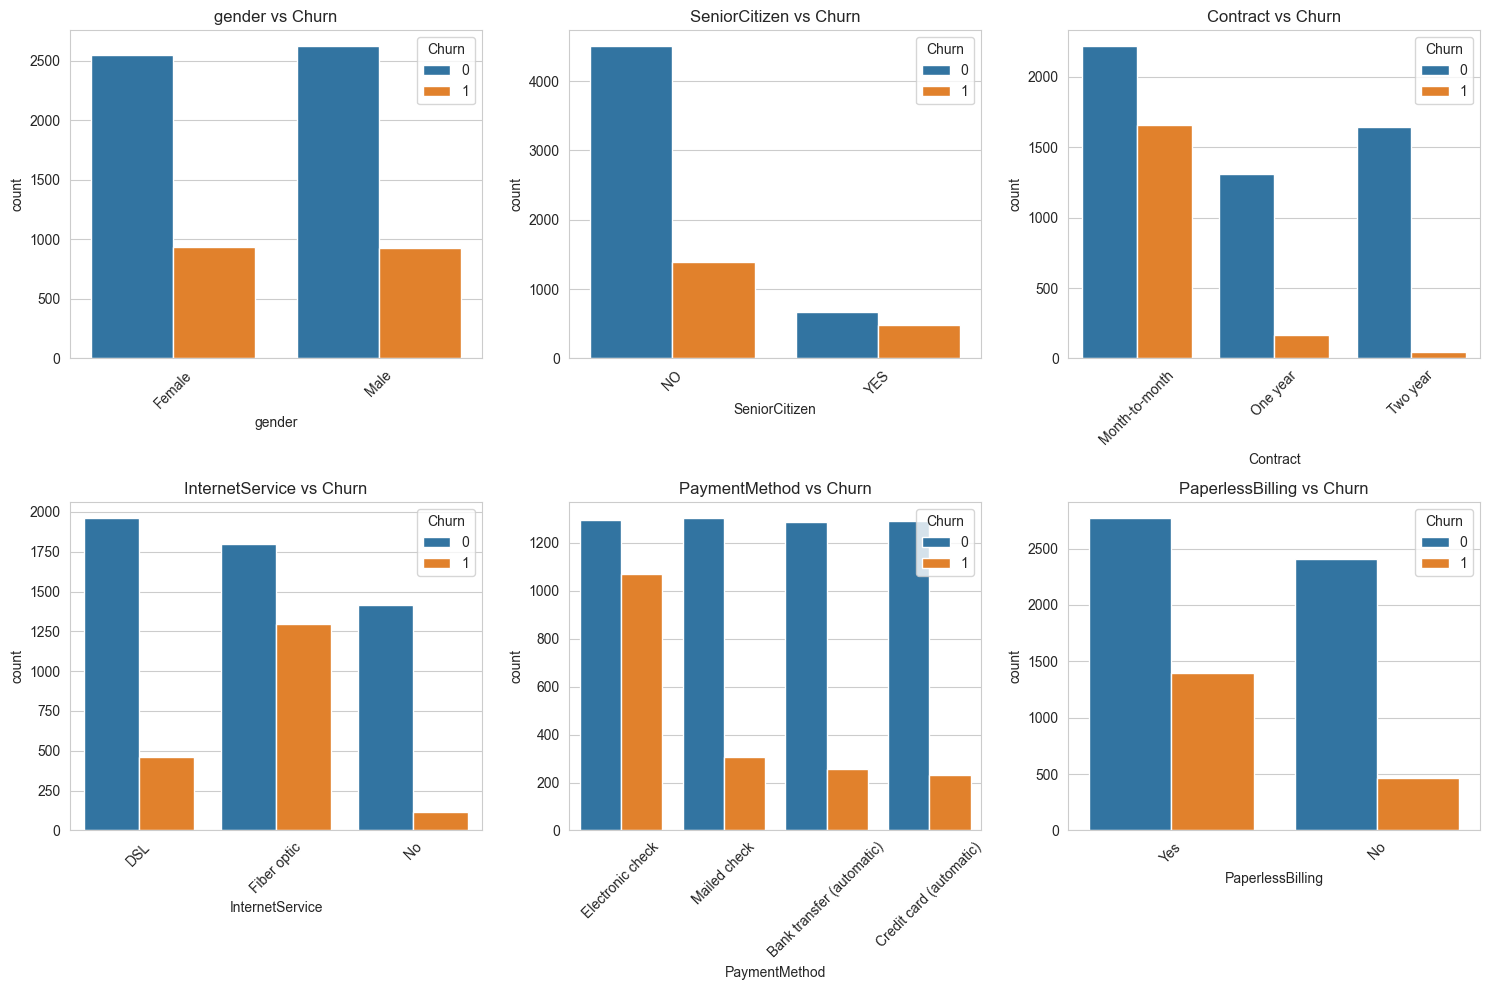

In [5]:
# Plot top categories vs Churn
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plot_cols = ['gender', 'SeniorCitizen', 'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
for i, col in enumerate(plot_cols):
    row, col_idx = divmod(i, 3)
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs Churn')
    axes[row, col_idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

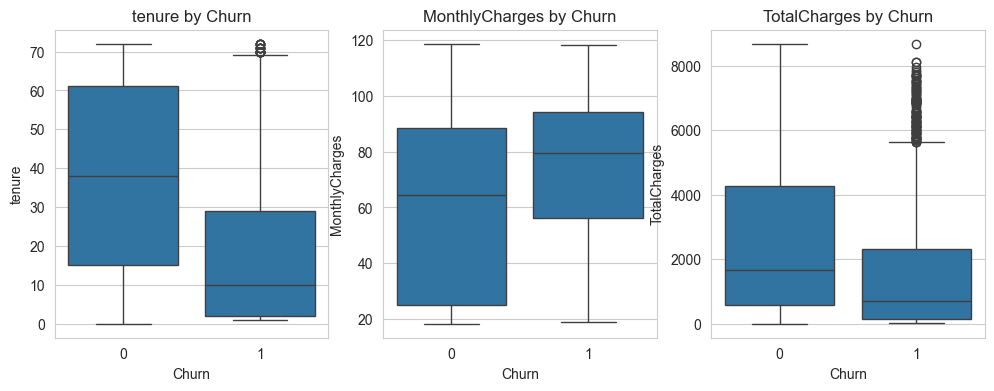

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.show()

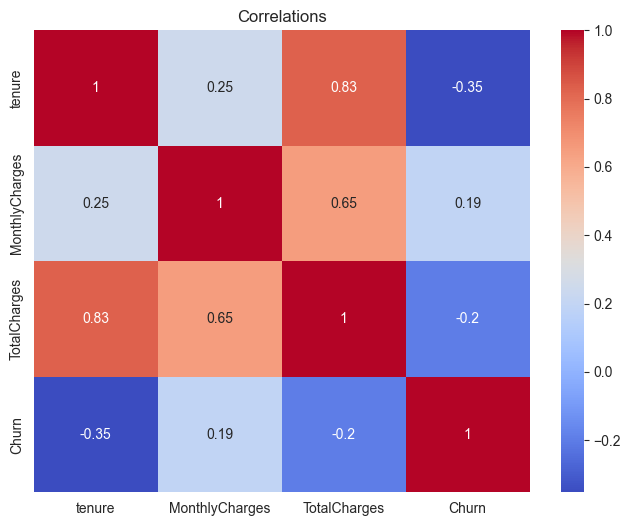

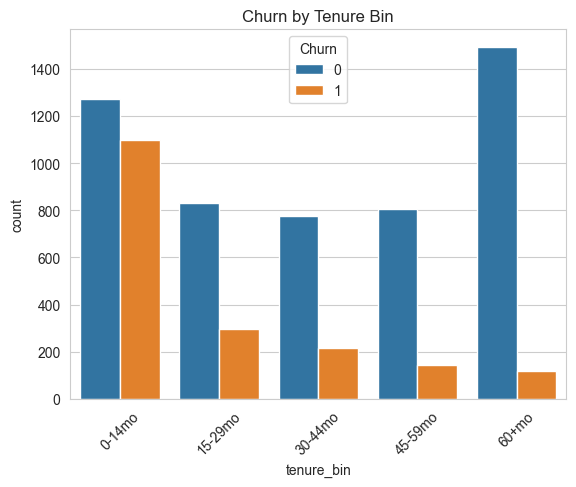

High-Risk Group Churn Rate: 73.12072892938497 %


In [7]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['Churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlations')
plt.show()

# Tenure bins for patterns
df['tenure_bin'] = pd.cut(df['tenure'], bins=5, labels=['0-14mo', '15-29mo', '30-44mo', '45-59mo', '60+mo'])
sns.countplot(data=df, x='tenure_bin', hue='Churn')
plt.title('Churn by Tenure Bin')
plt.xticks(rotation=45)
plt.show()

# High-risk interaction
df['high_risk'] = (df['MonthlyCharges'] > 80) & (df['tenure'] < 12)
print("High-Risk Group Churn Rate:", df[df['high_risk']]['Churn'].mean() * 100, "%")  # ~50%

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features (X) & Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split: 70% train, 30% test (holdout for fairness)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Preprocess: Scale numbers, dummy text
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ])

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

print("Train Shape:", X_train_pre.shape)  # ~45 features after dummies

Train Shape: (4930, 23)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Models (simple to elite)
lr = LogisticRegression(random_state=42).fit(X_train_pre, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_pre, y_train)
xgb = XGBClassifier(n_estimators=200, random_state=42).fit(X_train_pre, y_train)

# Test scores
models = {'Logistic': lr, 'Random Forest': rf, 'XGBoost': xgb}
for name, model in models.items():
    y_pred = model.predict(X_test_pre)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_pre)[:, 1])
    print(f"{name}: Accuracy {accuracy_score(y_test, y_pred):.1%} | AUC {auc:.3f}")

Logistic: Accuracy 81.0% | AUC 0.845
Random Forest: Accuracy 78.6% | AUC 0.822
XGBoost: Accuracy 78.7% | AUC 0.815
